In [ ]:
from dataclasses import dataclass
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd

num_bits = 6
num_states = 2 ** num_bits

In [ ]:
# Define possible cost functions
def cost_quadratic(x):
    return (x - 3)**2 + 1

def cost_linear(x):
    return x

# Produces the cost based on the application to max-cut
# E is the set of edges, provided as a list of duples of vertices (0-indexed)
# The ith least significant bit of x = the group the ith vertex belongs to
# this is the regular old max cut cost function
def cost_max_cut(E, x: int):
  cost = 0
  for v1, v2 in E:
    # group1 is 1 iff the v1-th bit is 1
    group1 = ((x >> v1) & 1)
    group2 = ((x >> v2) & 1)
    if (group1 != group2): cost += 1
  return cost

# Produces the cost based on an application to the partition problem
# nums is a list (or tuple) of the available numbers to partition
# The cost is equal to the min of each group's sum
# The bit string tells us which numbers are in the partition,
# and is ordered from LSB to MSB

def cost_partition(nums, x):
  sum_zeroes = 0
  sum_ones = 0
  for i, num in enumerate(nums):
    group = ((x >> i) & 1)
    if (group == 1): sum_ones += num
    else: sum_zeroes += num

  return min(sum_ones, sum_zeroes)

# Produces the cost based on an application of vertex cover
# We allow not all edges to be covered, but apply a penalty to uncovered edges
# E is the set of edges, provided as a list of duples of vertices (0-indexed)
# Cost is defined as num(vertices not chosen) + edge_cost * num(edges covered)
def cost_vertex_cover(E, x, edge_cost):
  max_vertex = max([i for (i,j) in E] + [j for (i,j) in E])
  num_vertices = max_vertex + 1
  vertices_chosen = [i for i in range(max_vertex + 1) if (x >> i) & 1]
  num_edges_covered = 0
  for edge in E:
    if edge[0] in vertices_chosen or edge[1] in vertices_chosen:
      num_edges_covered += 1
  return num_vertices - len(vertices_chosen) + edge_cost * num_edges_covered

def cost_array(arr, x):
  return arr[x]

In [ ]:
# Test out cost functions
E = [(0, 1), (0, 2), (0, 3), (2, 3)]
for i in range(2**4):
  print("x = ", np.binary_repr(i, 4), ":", sep = "")
  print("Max Cut:", cost_max_cut(E, i))
  print("Vertex Cover (edge_cost = 2):", cost_vertex_cover(E, i, 2))

nums = [1, 5, 11, 5]
print("Partition")
for i in range(2 ** 4):
  print(np.binary_repr(i, 4), ":", cost_partition(nums, i))

x = 0000:
Max Cut: 0
Vertex Cover (edge_cost = 2): 4
x = 0001:
Max Cut: 3
Vertex Cover (edge_cost = 2): 9
x = 0010:
Max Cut: 1
Vertex Cover (edge_cost = 2): 5
x = 0011:
Max Cut: 2
Vertex Cover (edge_cost = 2): 8
x = 0100:
Max Cut: 2
Vertex Cover (edge_cost = 2): 7
x = 0101:
Max Cut: 3
Vertex Cover (edge_cost = 2): 10
x = 0110:
Max Cut: 3
Vertex Cover (edge_cost = 2): 8
x = 0111:
Max Cut: 2
Vertex Cover (edge_cost = 2): 9
x = 1000:
Max Cut: 2
Vertex Cover (edge_cost = 2): 7
x = 1001:
Max Cut: 3
Vertex Cover (edge_cost = 2): 10
x = 1010:
Max Cut: 3
Vertex Cover (edge_cost = 2): 8
x = 1011:
Max Cut: 2
Vertex Cover (edge_cost = 2): 9
x = 1100:
Max Cut: 2
Vertex Cover (edge_cost = 2): 8
x = 1101:
Max Cut: 1
Vertex Cover (edge_cost = 2): 9
x = 1110:
Max Cut: 3
Vertex Cover (edge_cost = 2): 9
x = 1111:
Max Cut: 0
Vertex Cover (edge_cost = 2): 8
Partition
0000 : 0
0001 : 1
0010 : 5
0011 : 6
0100 : 11
0101 : 10
0110 : 6
0111 : 5
1000 : 5
1001 : 6
1010 : 10
1011 : 11
1100 : 6
1101 : 5
1110 : 1
1

In [ ]:
# Utilise flexible cost function
import pickle
E = pickle.loads(b'\x80\x04\x95;\x00\x00\x00\x00\x00\x00\x00]\x94(K\x00K\x01\x86\x94K\x01K\x02\x86\x94K\x02K\x00\x86\x94K\x03K\x05\x86\x94K\x04K\x03\x86\x94K\x05K\x04\x86\x94K\x00K\x03\x86\x94K\x01K\x04\x86\x94K\x02K\x05\x86\x94e.'
)
integer_valued_cost_function = lambda x: cost_max_cut(E, x)

 index bitstring  cost  Real  Imaginary  Argument  Probability
     0    000000     0 0.125          0       0.0     0.015625
     1    000001     3 0.125          0       0.0     0.015625
     2    000010     3 0.125          0       0.0     0.015625
     3    000011     4 0.125          0       0.0     0.015625
     4    000100     3 0.125          0       0.0     0.015625
     5    000101     4 0.125          0       0.0     0.015625
     6    000110     4 0.125          0       0.0     0.015625
     7    000111     3 0.125          0       0.0     0.015625
     8    001000     3 0.125          0       0.0     0.015625
     9    001001     4 0.125          0       0.0     0.015625
    10    001010     6 0.125          0       0.0     0.015625
    11    001011     5 0.125          0       0.0     0.015625
    12    001100     6 0.125          0       0.0     0.015625
    13    001101     5 0.125          0       0.0     0.015625
    14    001110     7 0.125          0       0.0     0

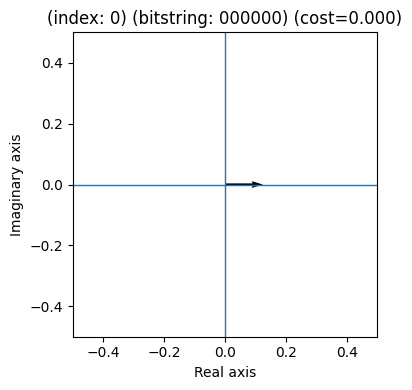

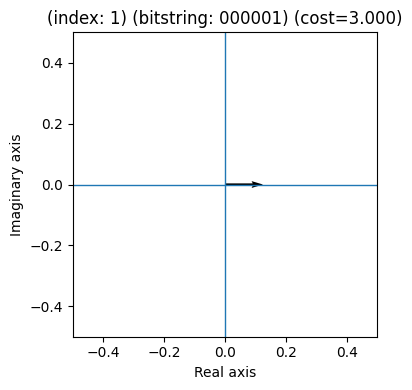

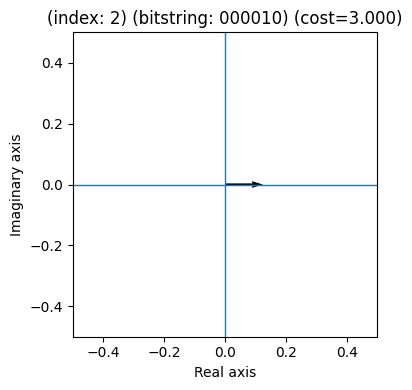

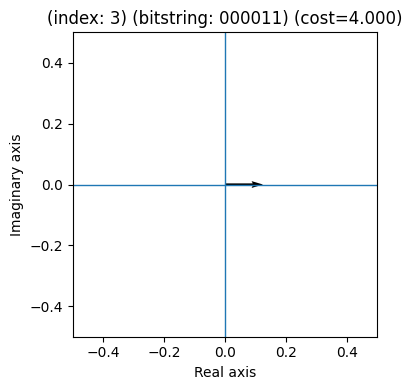

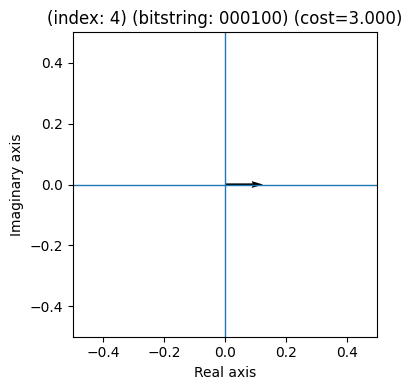

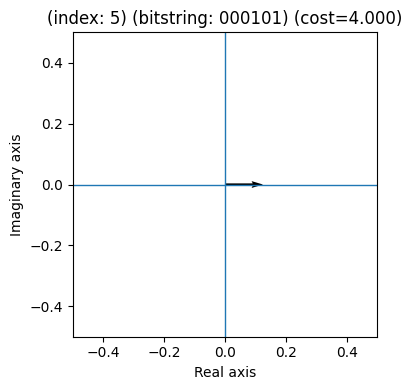

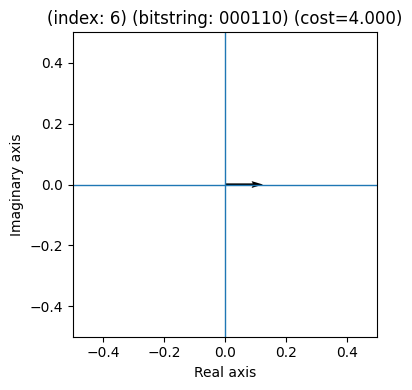

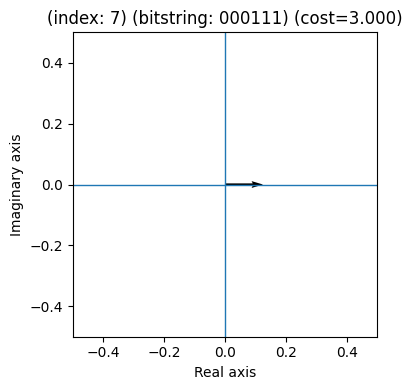

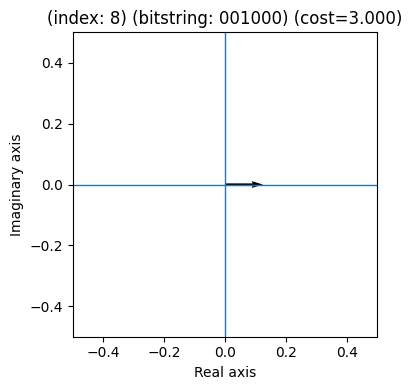

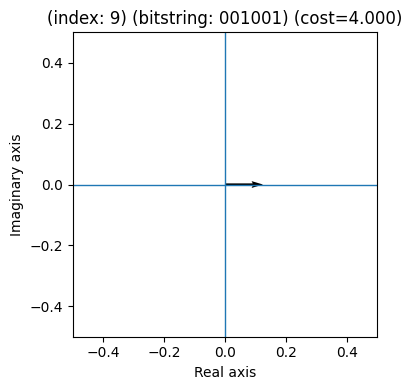

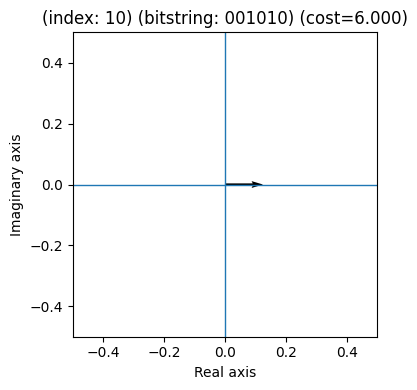

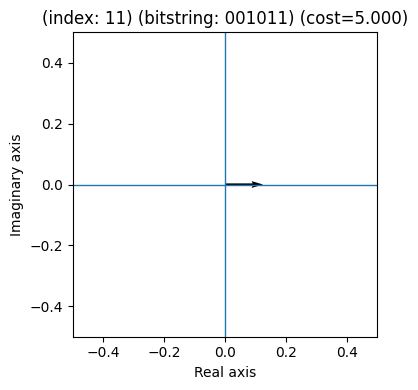

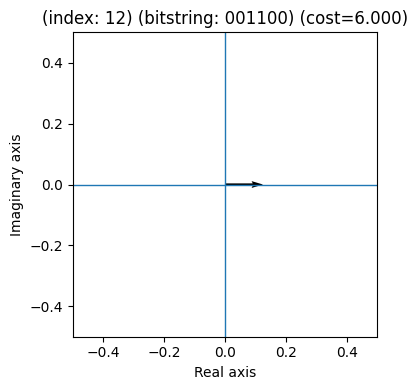

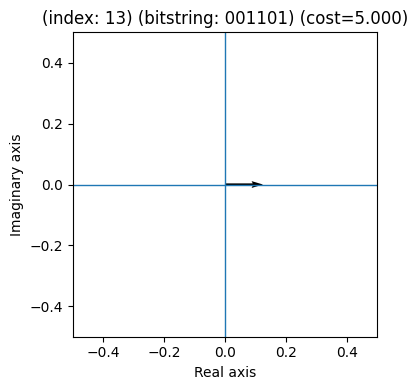

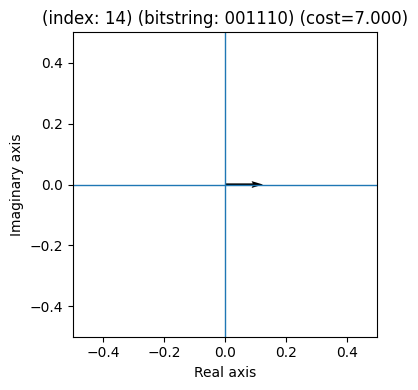

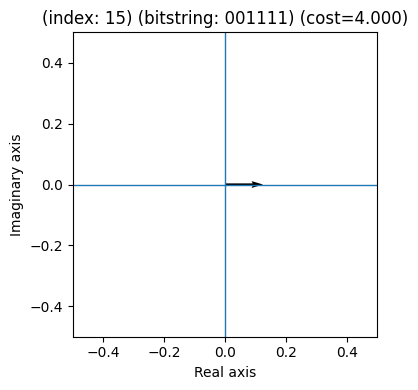

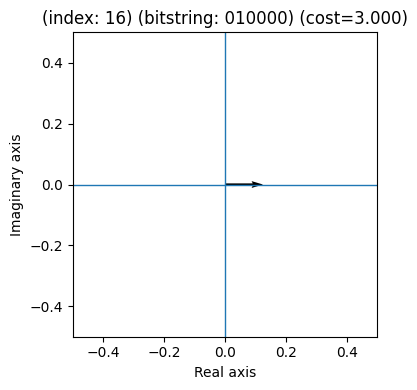

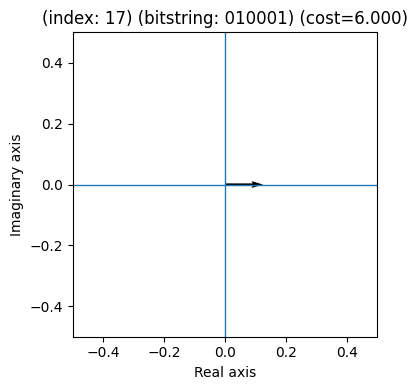

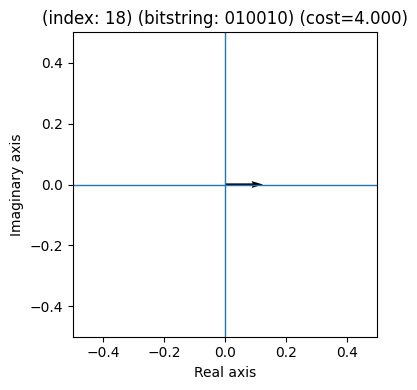

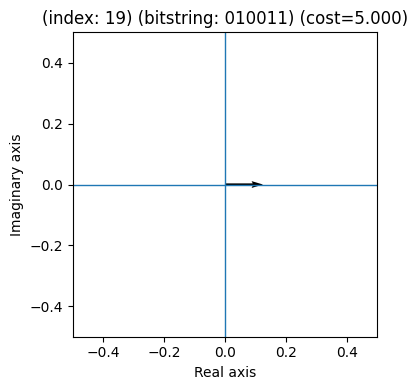

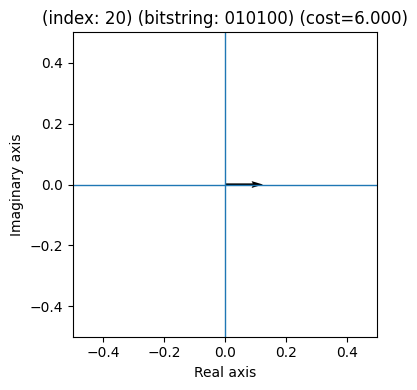

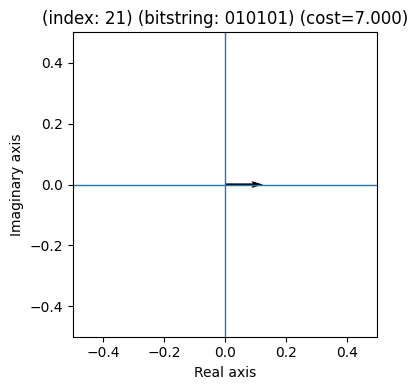

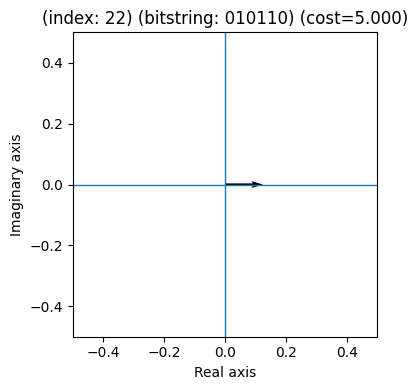

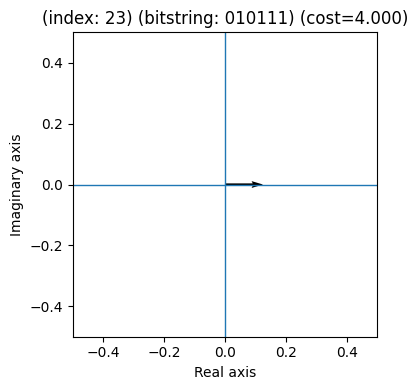

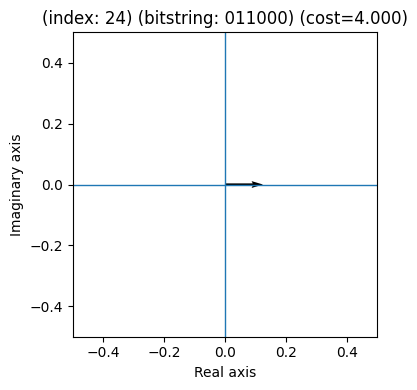

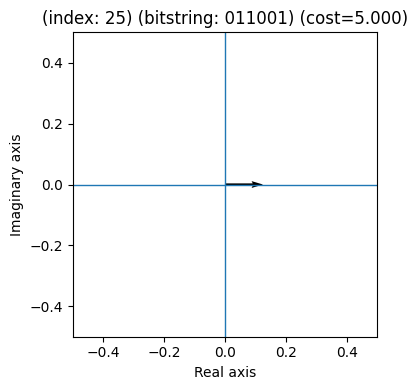

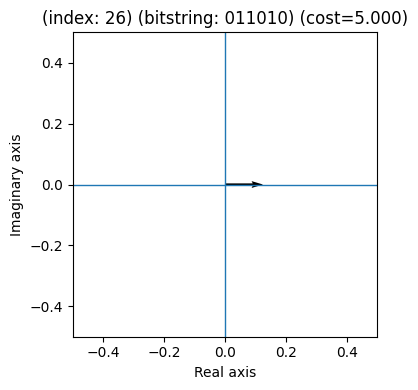

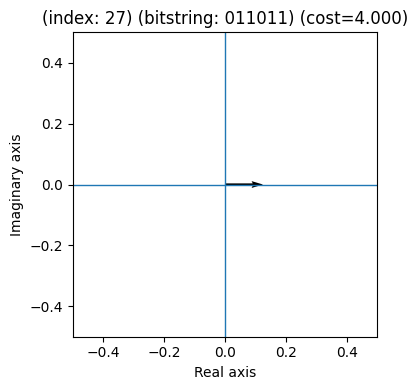

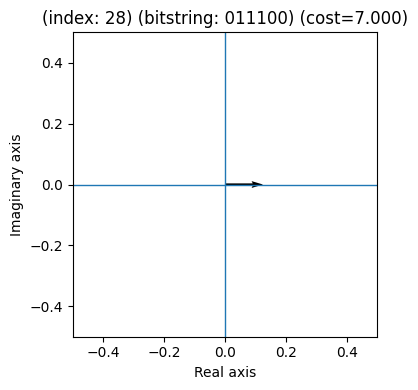

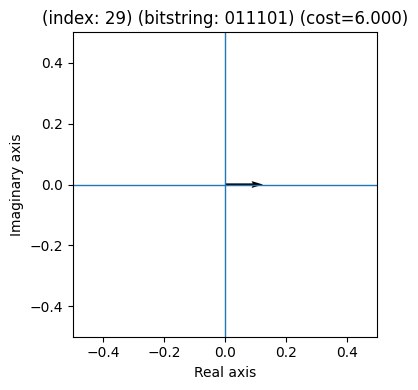

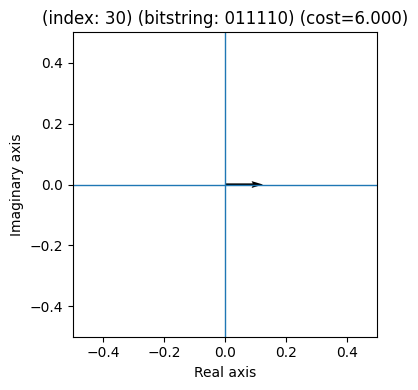

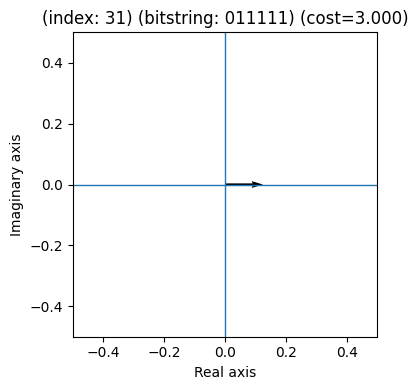

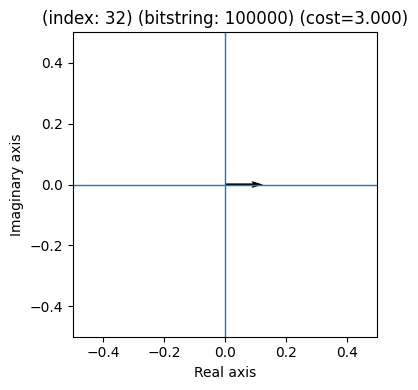

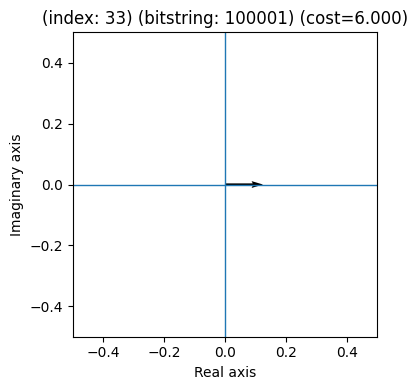

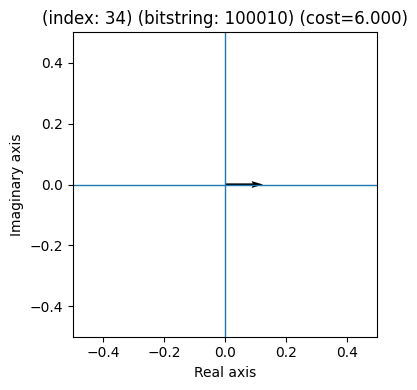

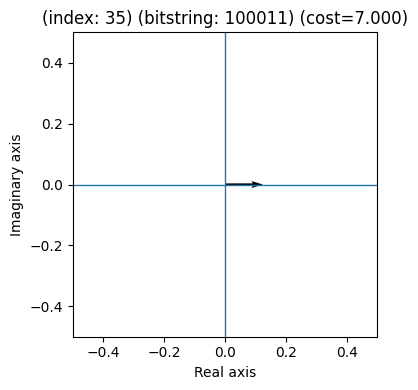

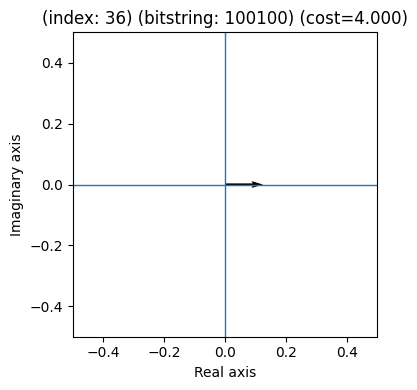

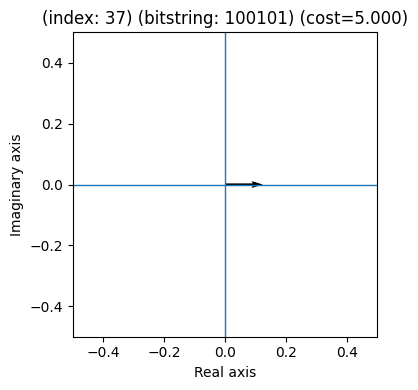

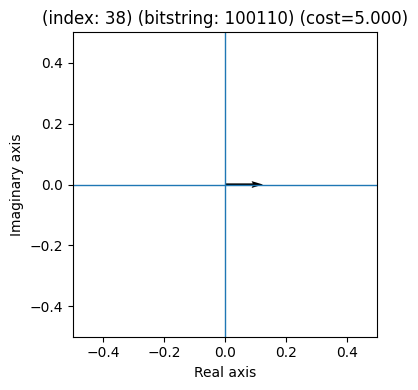

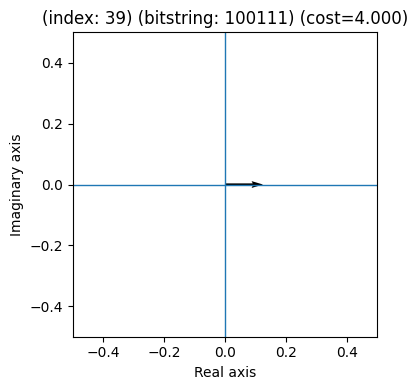

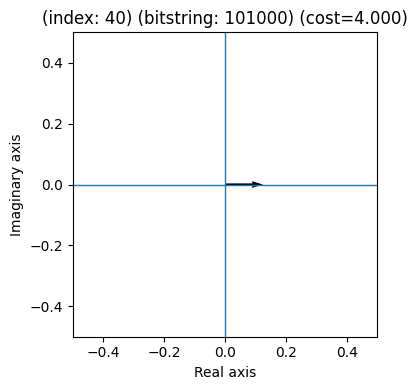

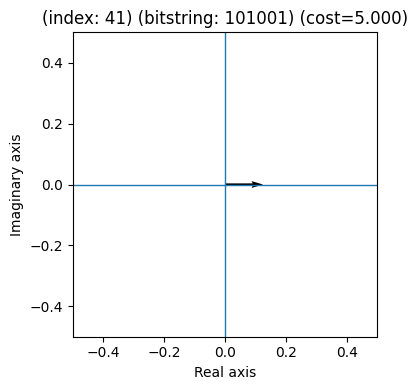

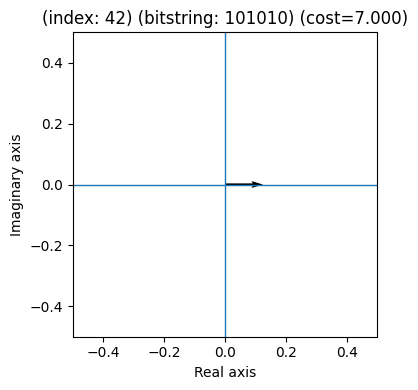

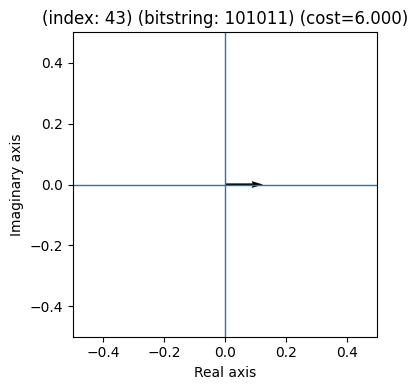

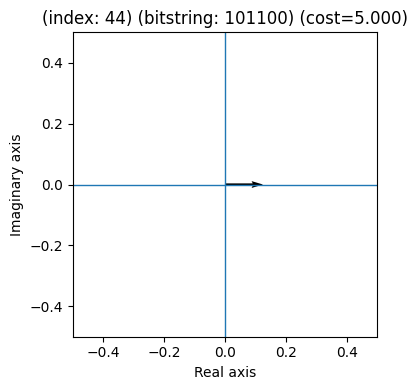

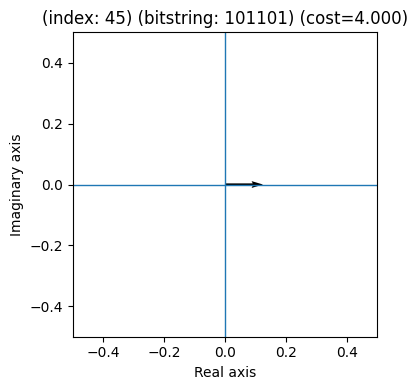

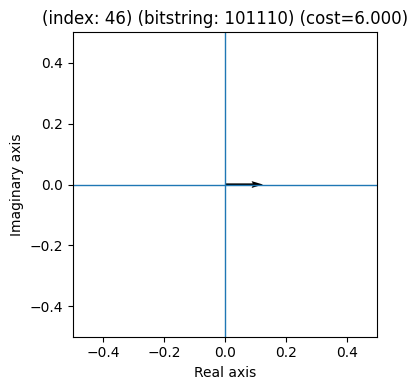

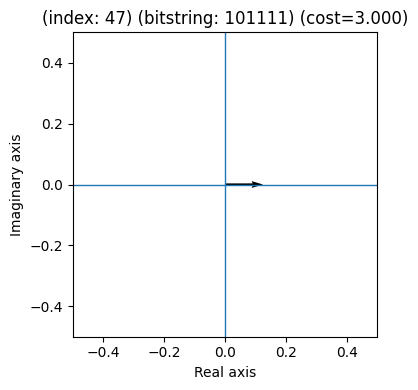

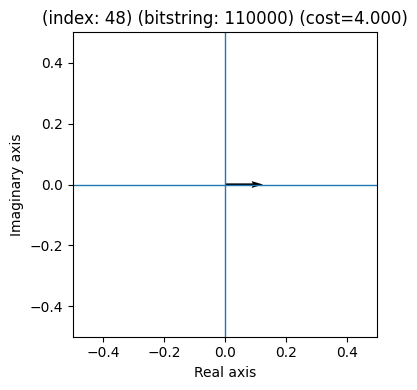

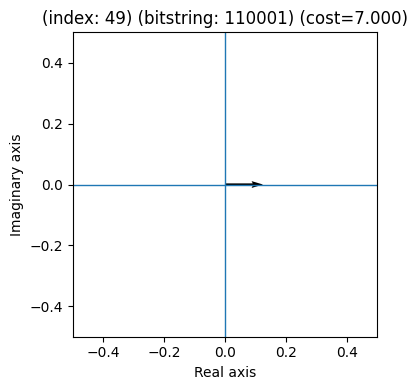

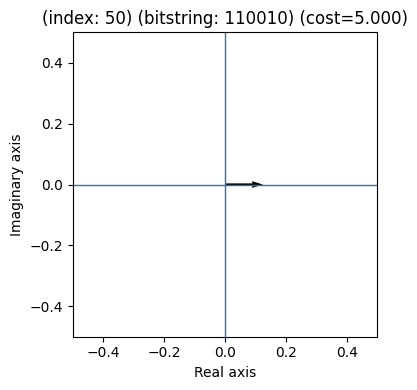

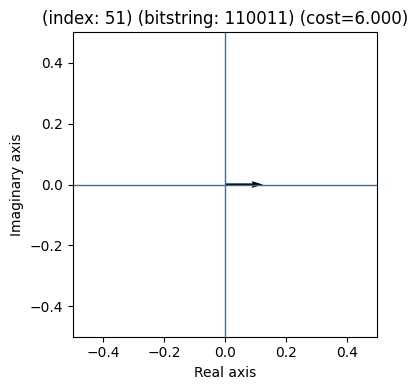

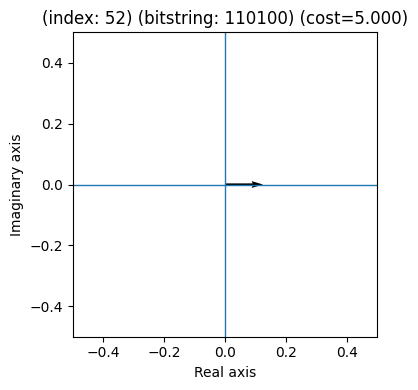

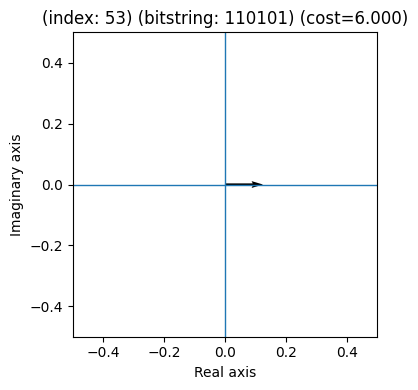

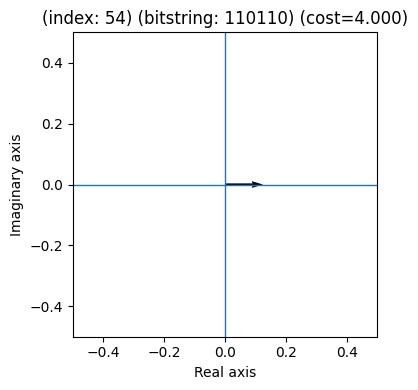

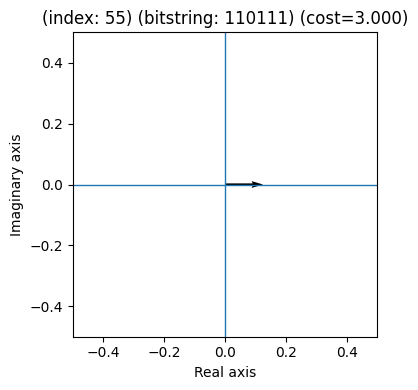

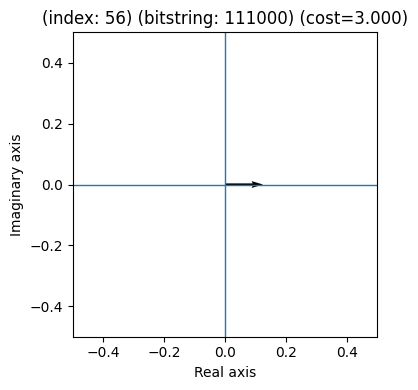

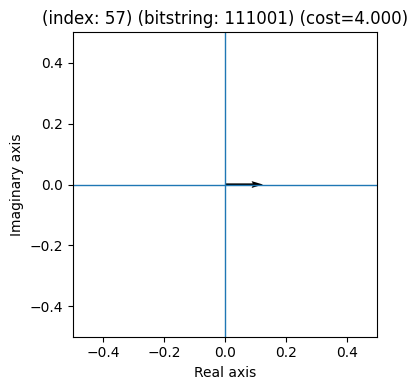

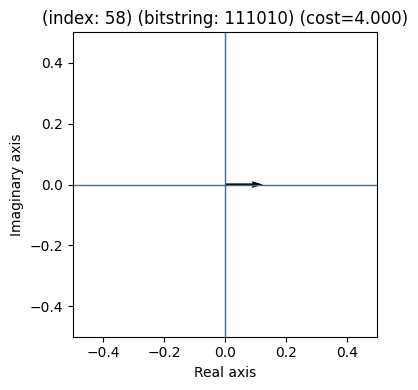

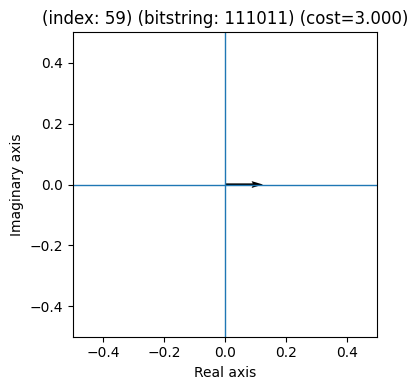

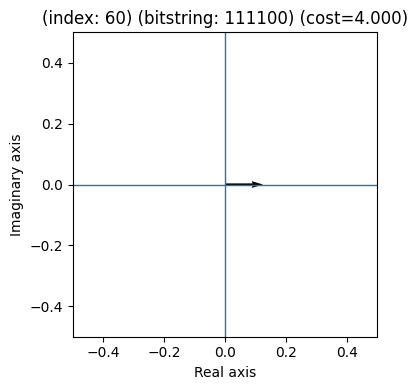

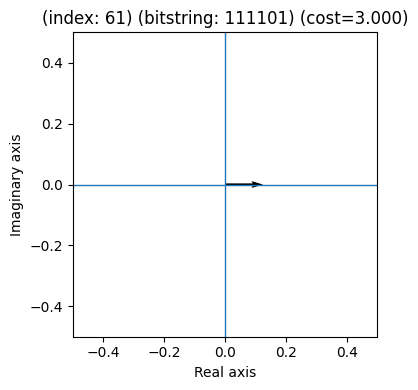

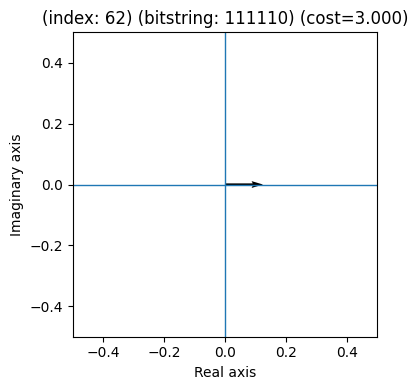

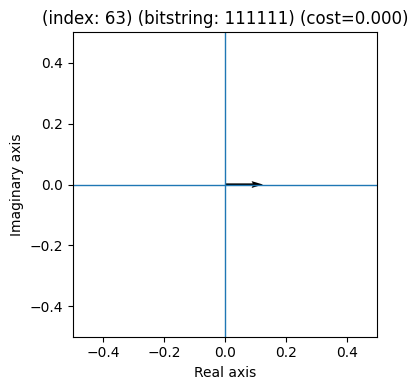

In [ ]:
# Create class for storing state vector of qubit strings
@dataclass
class BitState:
  index: int
  bitstring: str
  cost: float
  real_component: float
  imag_component: float
  @property
  def probability(self) -> float:
      return self.real_component**2 + self.imag_component**2 # = real_component^2 + imag_component^2)
  @property
  def complex_amp(self) -> complex:
      return complex(self.real_component, self.imag_component)

  @property
  def argument_degrees(self) -> float:
      return np.angle(self.complex_amp, deg = True)

initial_amplitude = 1/np.sqrt(num_states)
states = []

# Initialise all the bitstring states to equal amplitudes and initialise relevant information
for i in range(num_states):
  cost_value = integer_valued_cost_function(i)        # compute the corresponding cost of the bit via defined function

  states.append(BitState(
      index = i,
      bitstring = np.binary_repr(i, width=num_bits),  # Store the bitstring representation (converting i to binary)
      cost = cost_value,                              # Store computed cost
      real_component=initial_amplitude,               # Initialise to only real axis
      imag_component=0))                              # Initialise imaginary axis to 0


# Create pandas dataframe for storing all information
df = pd.DataFrame([
    {
        "index": s.index,
        "bitstring": s.bitstring,
        "cost": s.cost,
        "Real": s.real_component,
        "Imaginary": s.imag_component,
        "Argument": s.argument_degrees,
        "Probability": s.probability,
    }
    for s in states
]).sort_values("index")

# print table
print(df.to_string(index=False))


# Plot the argand diagram for a given state.
def plot_state_vector(state):

    re = float(state.real_component)
    im = float(state.imag_component)

    plt.figure(figsize=(4, 4))
    # Arrow from origin to (Re, Im)
    plt.quiver(0.0, 0.0, re, im, angles="xy", scale_units="xy", scale=1)

    # Axes and cosmetics
    plt.axhline(0, lw=1); plt.axvline(0, lw=1)
    lim = max(1.1 * max(abs(re), abs(im), 1e-12), 0.5)
    plt.xlim(-lim, lim); plt.ylim(-lim, lim)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel("Real axis"); plt.ylabel("Imaginary axis")
    plt.title(f"(index: {state.index}) (bitstring: {state.bitstring}) (cost={state.cost:.3f})")
    plt.tight_layout()
    plt.show()

# Plot argand diagram for all state vectors
for s in states:
  plot_state_vector(s)

In [ ]:
def apply_phase_separator(states, gamma):
  for state in states:
    rotation = np.exp(-1j * gamma * state.cost)
    new_value = state.complex_amp * rotation
    state.real_component = new_value.real
    state.imag_component = new_value.imag

In [ ]:
from scipy.linalg import expm

pauli_x = np.array([[0, 1],
                    [1, 0]])


def calculate_pauli(num_bits):
  paulis = []
  for i in range(num_bits):
    pauli = np.identity(1)
    for j in range(num_bits):
      if (i != j):
        pauli = np.kron(pauli, np.identity(2))
      else:
        pauli = np.kron(pauli, pauli_x)

    paulis.append(pauli)
  pauli_sum = np.add.reduce(paulis)

  return pauli_sum

"""
pauli = calculate_pauli(2)
pauli_exp = expm(1j * math.pi/8 * pauli)
pauli_exp = np.round(pauli_exp, 1)
print(pauli)
print(pauli_exp)
"""

def apply_mixing_operator(states, pauli, beta):
  pauli_exp = expm(-1j * beta * pauli)
  state_values = np.array([state.complex_amp for state in states])
  state_values = pauli_exp.dot(state_values)
  for i, state in enumerate(states):
    state.real_component = state_values[i].real
    state.imag_component = state_values[i].imag





,index,bitstring,cost,Real,Imaginary,Probability
0,0,000000,0,0.024616,0.018443,0.000946
63,63,111111,0,0.024616,0.018443,0.000946
2,2,000010,3,0.011449,0.046201,0.002266
1,1,000001,3,0.011449,0.046201,0.002266
7,7,000111,3,-0.058634,0.027895,0.004216
...,...,...,...,...,...,...
21,21,010101,7,-0.122342,0.200731,0.055260
28,28,011100,7,-0.122342,0.200731,0.055260
35,35,100011,7,-0.122342,0.200731,0.055260
42,42,101010,7,-0.122342,0.200731,0.055260


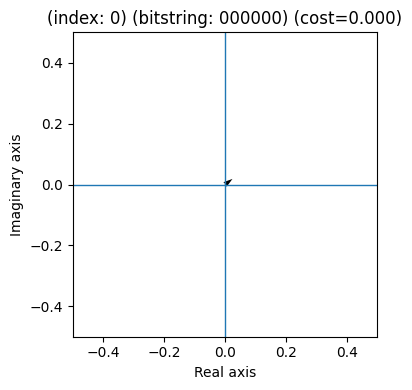

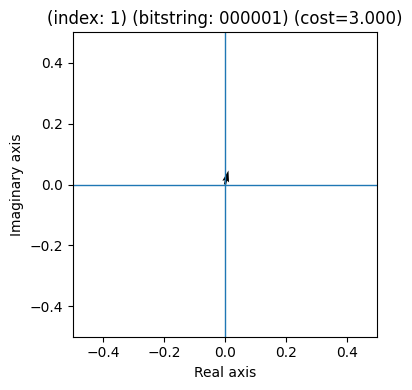

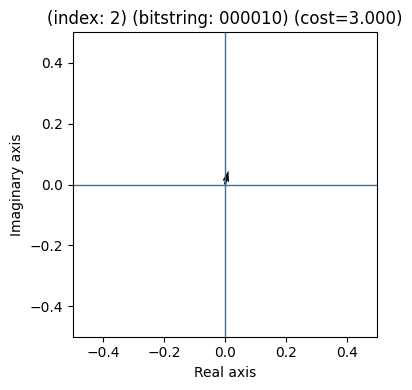

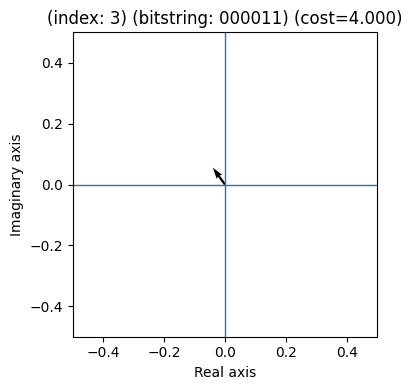

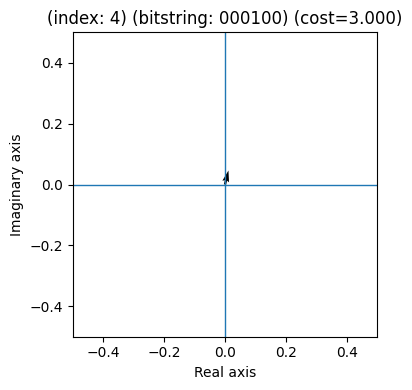

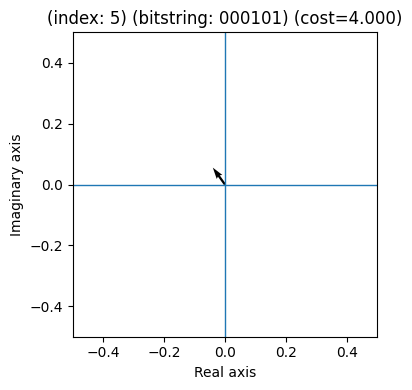

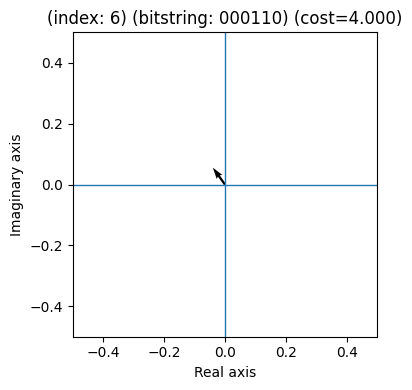

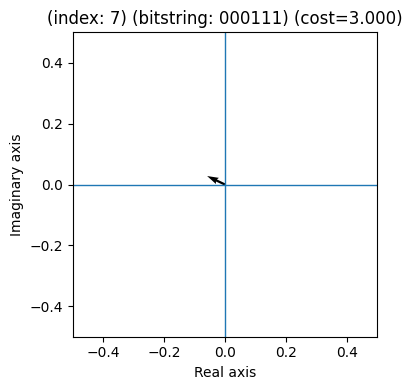

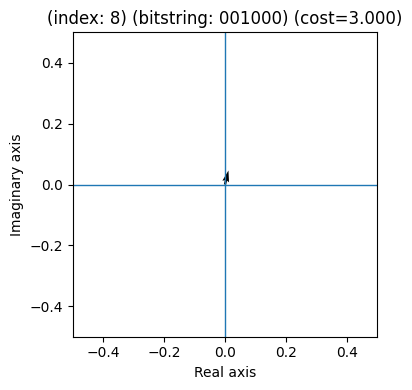

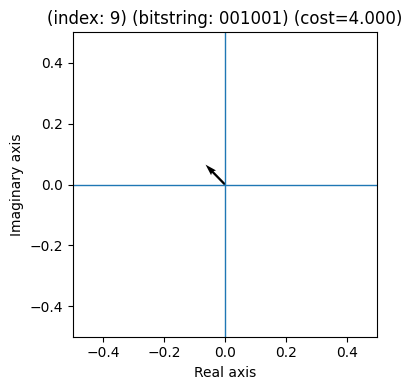

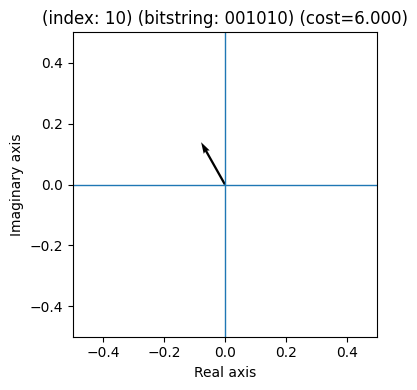

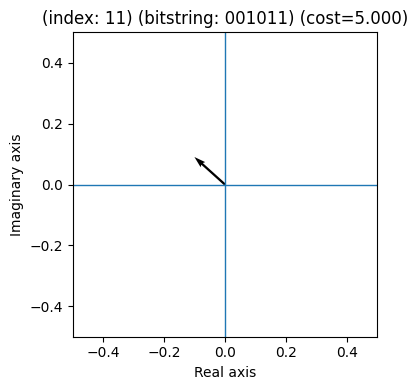

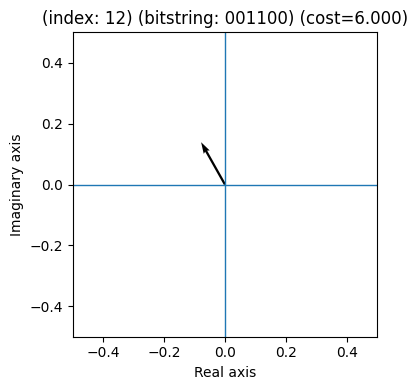

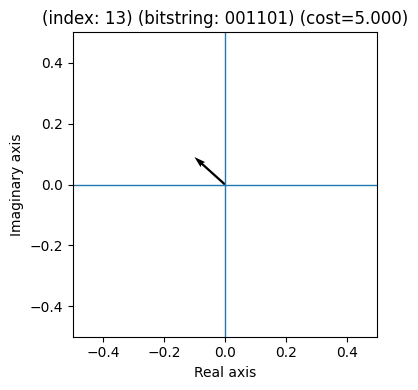

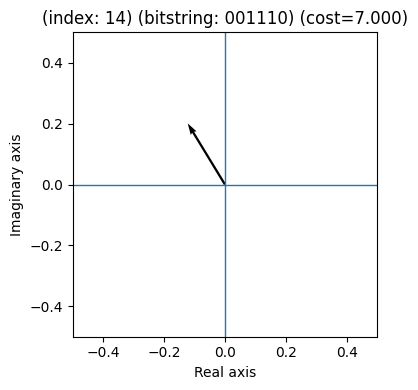

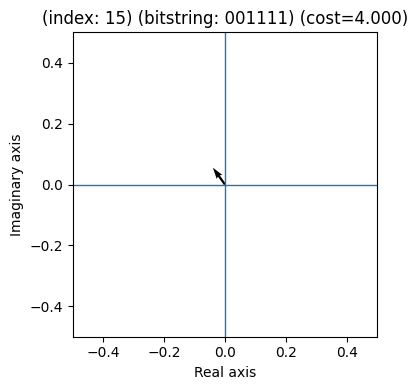

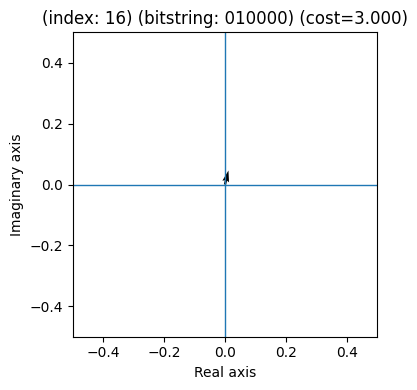

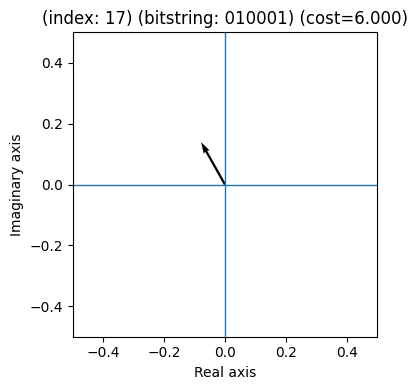

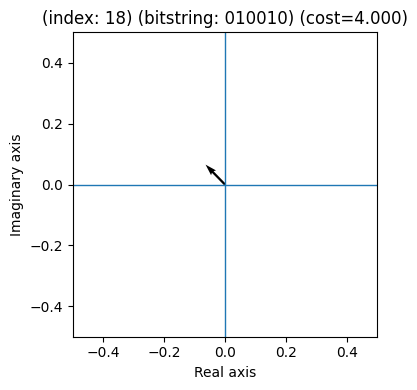

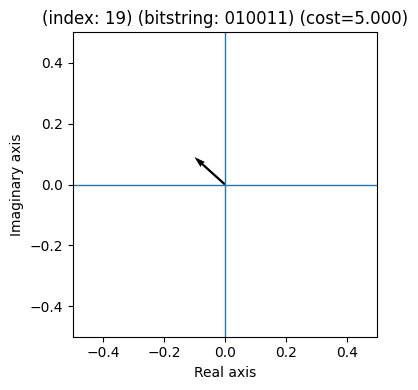

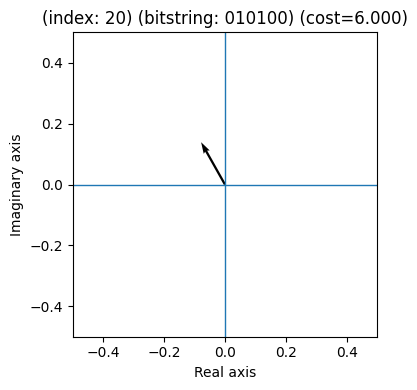

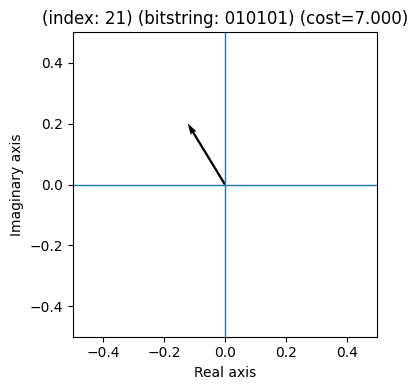

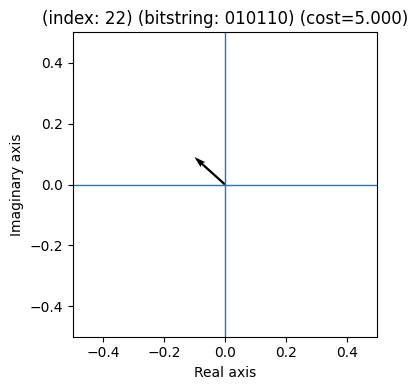

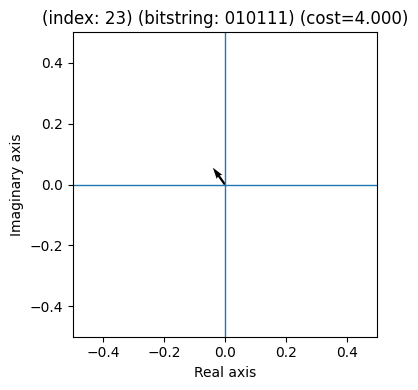

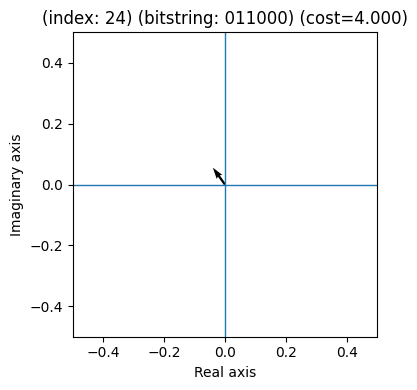

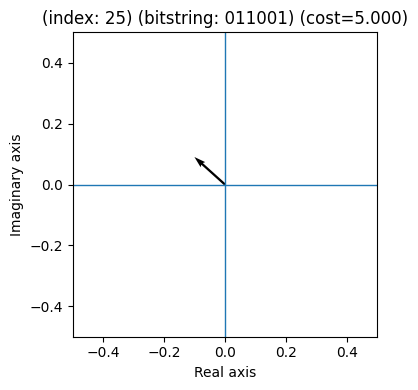

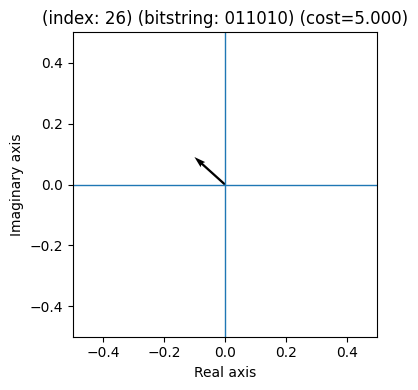

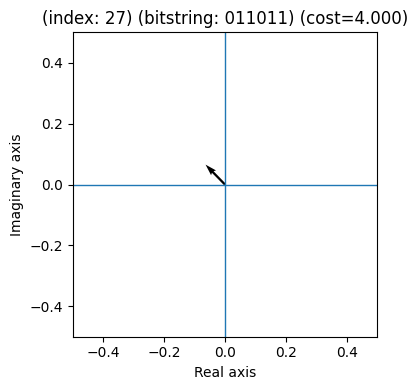

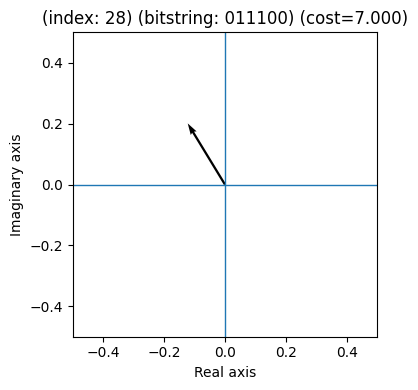

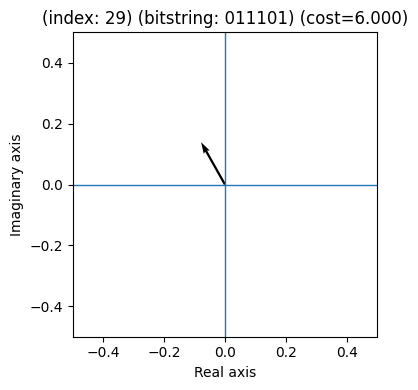

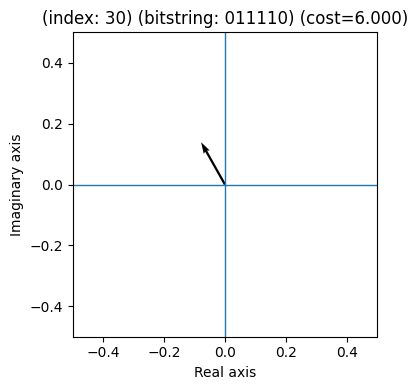

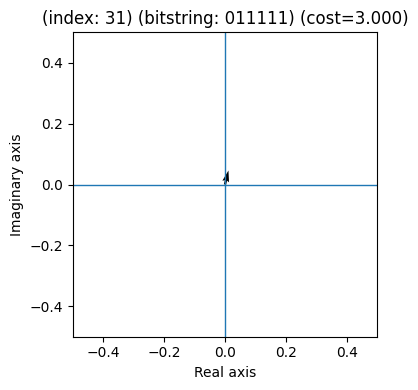

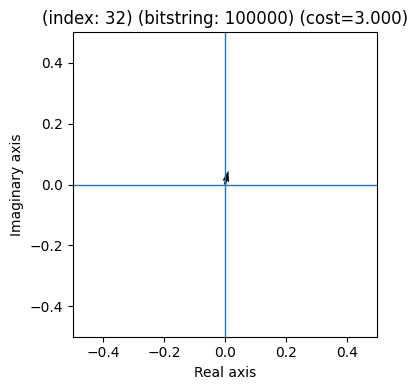

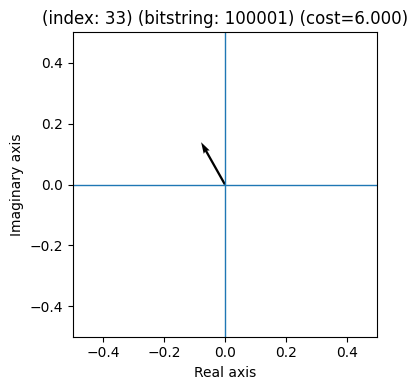

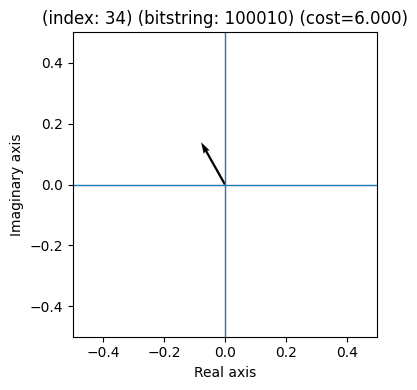

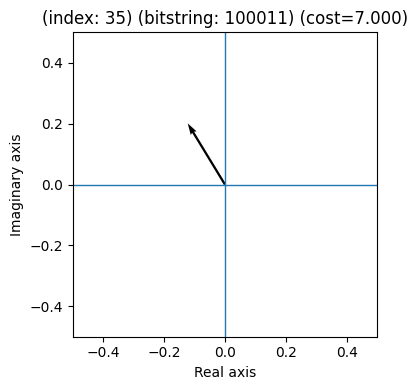

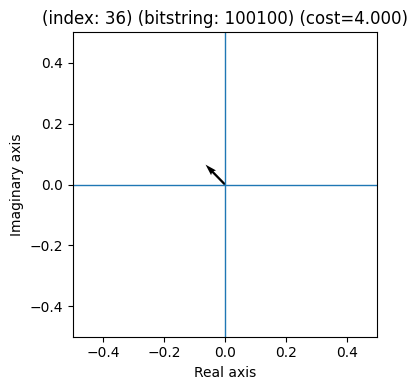

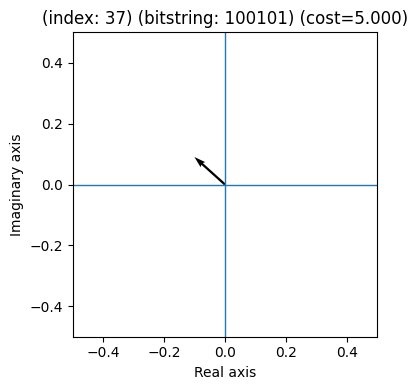

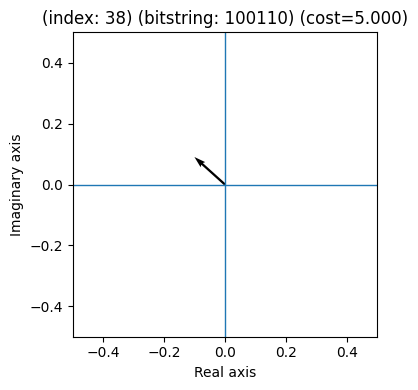

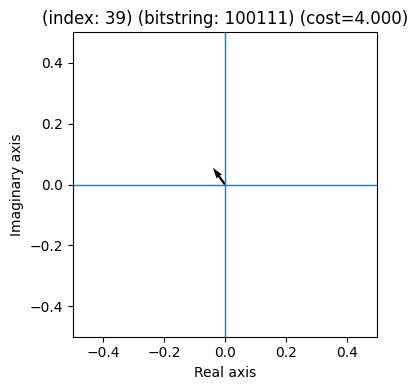

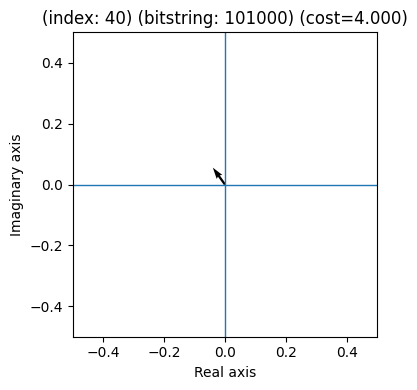

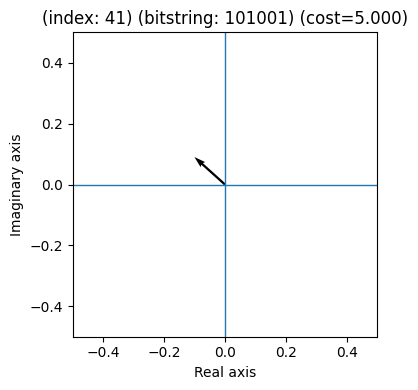

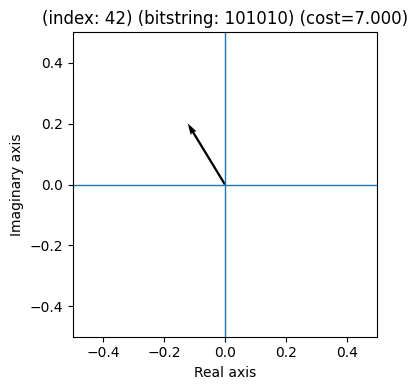

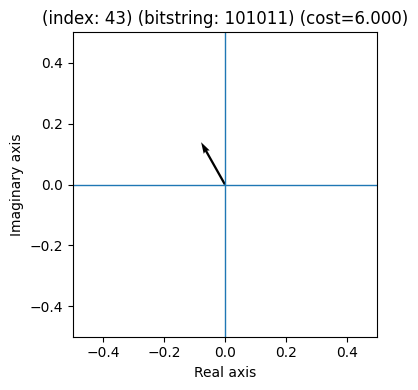

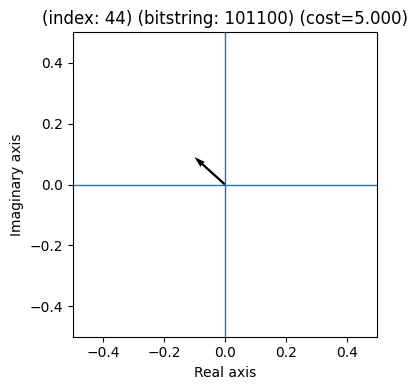

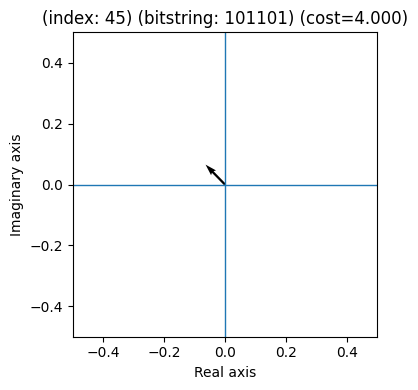

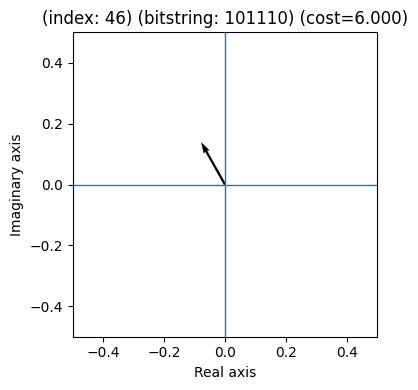

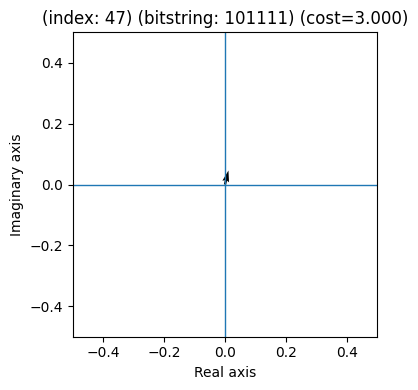

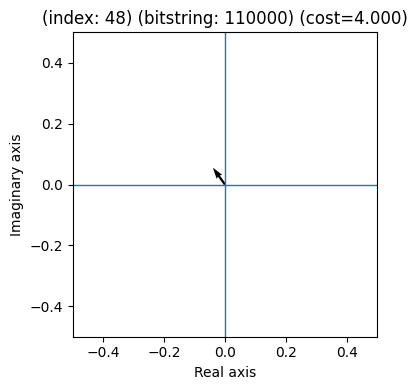

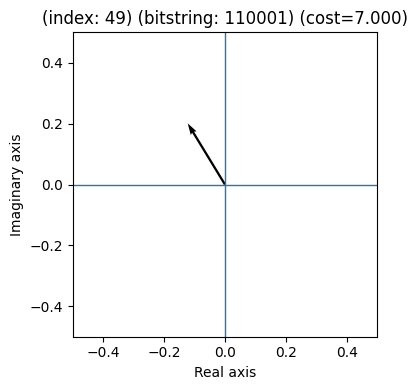

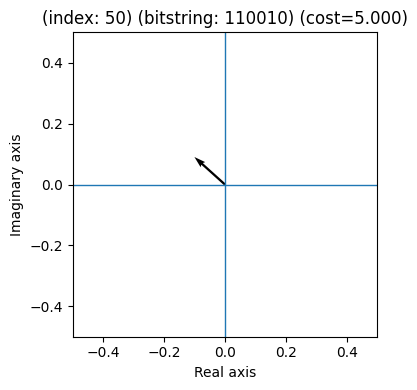

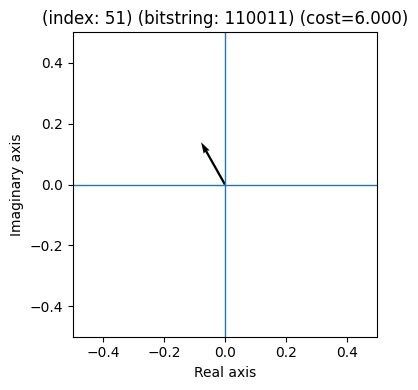

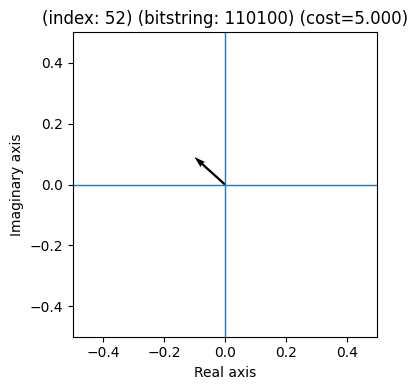

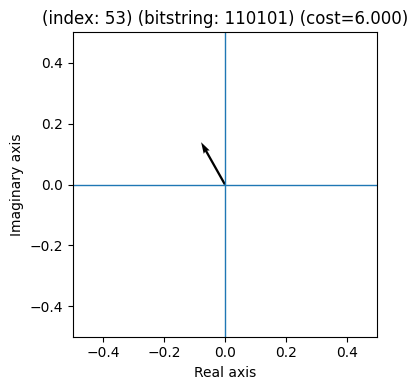

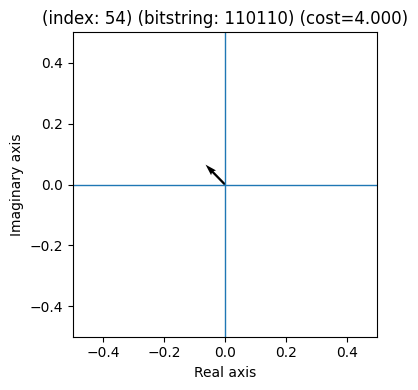

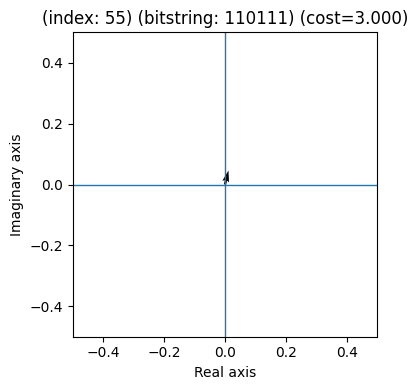

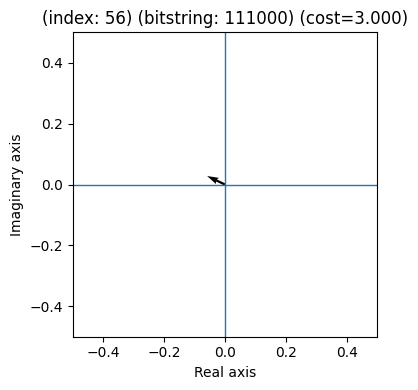

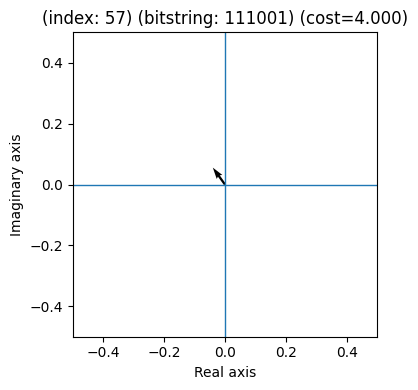

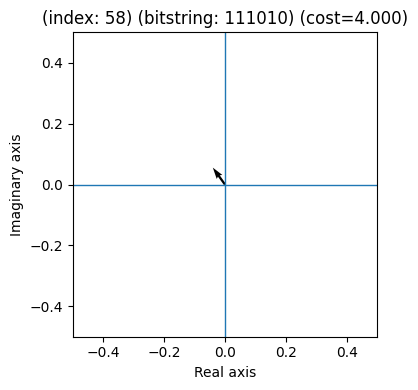

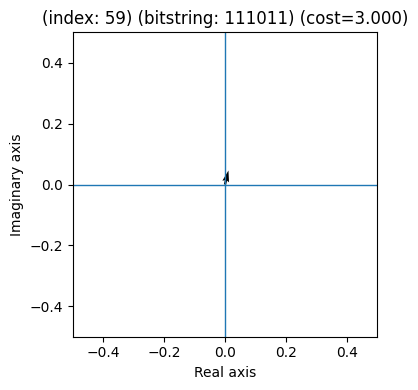

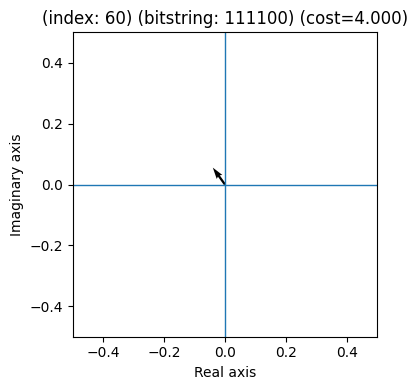

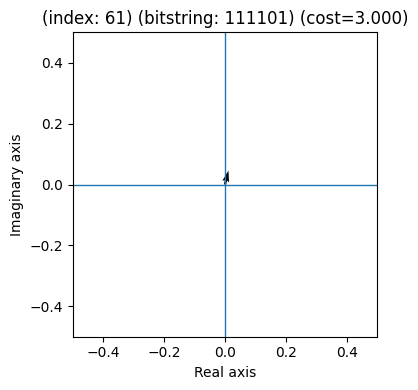

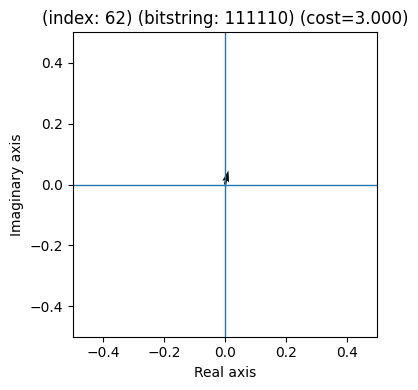

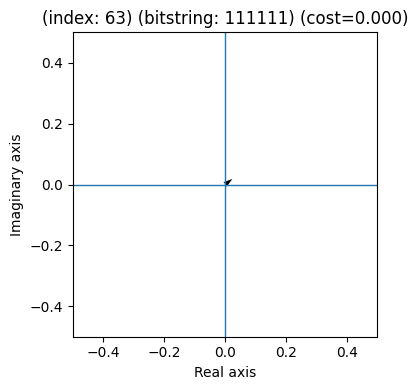

In [ ]:
def run(gamma, beta, p):

  states = []

  # Initialise all the bitstring states to equal amplitudes and initialise relevant information
  for i in range(num_states):
    cost_value = integer_valued_cost_function(i)        # compute the corresponding cost of the bit via defined function

    states.append(BitState(
        index = i,
        bitstring = np.binary_repr(i, width=num_bits),  # Store the bitstring representation (converting i to binary)
        cost = cost_value,                              # Store computed cost
        real_component=initial_amplitude,               # Initialise to only real axis
        imag_component=0))                              # Initialise imaginary axis to 0


  pauli = calculate_pauli(len(states[0].bitstring))
  for i in range(p):
    apply_phase_separator(states, gamma)
    apply_mixing_operator(states, pauli, beta)

  df = pd.DataFrame([
      {
          "index": s.index,
          "bitstring": s.bitstring,
          "cost": s.cost,
          "Real": s.real_component,
          "Imaginary": s.imag_component,
          "Probability": s.probability,
      }
      for s in states
  ]).sort_values("cost")

  return (df, states)

# print table
df, states = run(math.pi/8, math.pi/8, 1)
display(df)
for state in states:
  plot_state_vector(state)

In [ ]:
qiskit_results = pickle.loads(b'\x80\x04\x95E\x03\x00\x00\x00\x00\x00\x00]\x94(K\x00G?\xc6$\xdd/\x1a\x9f\xbe\x86\x94K\x01G?}}\xbfH\x7f\xcb\x92\x86\x94K\x02G?h\x93t\xbcj~\xfa\x86\x94K\x03G?\xa0\x13\xa9*0U2\x86\x94K\x04G?\x91hr\xb0 \xc4\x9c\x86\x94K\x05G?tz\xe1G\xae\x14{\x86\x94K\x06G?\x8a\x9f\xbev\xc8\xb49\x86\x94K\x07G?\xadp\xa3\xd7\n=q\x86\x94K\x08G?rn\x97\x8dO\xdf;\x86\x94K\tG?\x9f\x06\xf6\x94Fs\x82\x86\x94K\nG?t\xe3\xbc\xd3Z\x85\x88\x86\x94K\x0bG?uL\x98_\x06\xf6\x94\x86\x94K\x0cG?R\x05\xbc\x01\xa3n/\x86\x94K\rG?X\x93t\xbcj~\xfa\x86\x94K\x0eG?c\xa9*0U2a\x86\x94K\x0fG?\x84\xe3\xbc\xd3Z\x85\x88\x86\x94K\x10G?|\xac\x081&\xe9y\x86\x94K\x11G?l\xac\x081&\xe9y\x86\x94K\x12G?\x9e\x83\xe4%\xae\xe62\x86\x94K\x13G?v\x87+\x02\x0cI\xba\x86\x94K\x14G?R\x05\xbc\x01\xa3n/\x86\x94K\x15G?`bM\xd2\xf1\xa9\xfc\x86\x94K\x16G?ie+\xd3\xc3a\x13\x86\x94K\x17G?\x88\xc7\xe2\x82@\xb7\x80\x86\x94K\x18G?\x89\x99\x99\x99\x99\x99\x9a\x86\x94K\x19G?[\xdaQ\x19\xce\x07_\x86\x94K\x1aG?*6\xe2\xeb\x1cC-\x86\x94K\x1bG?\xa6\xa1a\xe4\xf7e\xfe\x86\x94K\x1cG?j6\xe2\xeb\x1cC-\x86\x94K\x1dG?f\xf0\x06\x8d\xb8\xba\xc7\x86\x94K\x1eG?X\x93t\xbcj~\xfa\x86\x94K\x1fG?c\xa9*0U2a\x86\x94K G?j6\xe2\xeb\x1cC-\x86\x94K!G?]}\xbfH\x7f\xcb\x92\x86\x94K"G?b\x05\xbc\x01\xa3n/\x86\x94K#G?_!-w1\x8f\xc5\x86\x94K$G?\xa5\x8e!\x96R\xbd<\x86\x94K%G?:6\xe2\xeb\x1cC-\x86\x94K&G?R\x05\xbc\x01\xa3n/\x86\x94K\'G?\x85\x18*\x990\xbe\x0e\x86\x94K(G?\x87X\xe2\x19e+\xd4\x86\x94K)G?k\xdaQ\x19\xce\x07_\x86\x94K*G?h\x93t\xbcj~\xfa\x86\x94K+G?a4\x04\xeaJ\x8c\x15\x86\x94K,G?r\xd7s\x18\xfcPH\x86\x94K-G?\x9dc\x88e\x94\xafO\x86\x94K.G?v\xf0\x06\x8d\xb8\xba\xc7\x86\x94K/G?}}\xbfH\x7f\xcb\x92\x86\x94K0G?\x83\xdd\x97\xf6+j\xe8\x86\x94K1G?dz\xe1G\xae\x14{\x86\x94K2G?_!-w1\x8f\xc5\x86\x94K3G?]}\xbfH\x7f\xcb\x92\x86\x94K4G?o\xf2\xe4\x8e\x8aq\xde\x86\x94K5G?wX\xe2\x19e+\xd4\x86\x94K6G?\xa2\xbd<6\x114\x05\x86\x94K7G?u\xb5s\xea\xb3g\xa1\x86\x94K8G?\xaei\xadB\xc3\xc9\xef\x86\x94K9G?\x88_\x06\xf6\x94Ft\x86\x94K:G?rn\x97\x8dO\xdf;\x86\x94K;G?\x90\xcb)^\x9e\x1b\t\x86\x94K<G?\x9e\xec\xbf\xb1[W?\x86\x94K=G?k\x08\x9a\x02u%F\x86\x94K>G?\x7f!-w1\x8f\xc5\x86\x94K?G?\xc5\xccc\xf1A \\\x86\x94e.'
)
print(qiskit_results[0])
print(sum([s.probability for s in states]))

(0, 0.173)
0.9999999999999998


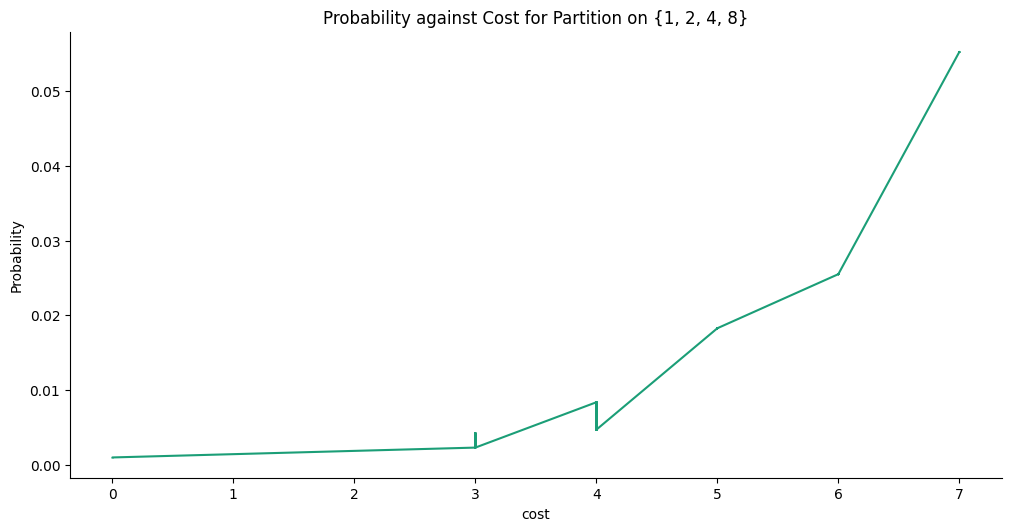

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['cost']
  ys = series['Probability']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('cost', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('cost')
plt.title('Probability against Cost for Partition on {1, 2, 4, 8}')
_ = plt.ylabel('Probability')
plt.savefig("graph.png")

In [ ]:
def expected_cost(states):
  return sum([s.probability * s.cost for s in states])

def expected_accuracy(states):
  return expected_cost(states) / min([s.cost for s in states])

def average_cost(states):
  return sum([s.cost for s in states]) / len(states)

expected_cost(states)

np.float64(5.704110273811421)

In [ ]:
gammas = [math.pi / i for i in range(4, 20)]
betas = [math.pi / 8 * i for i in range(1,2)]
p = 1
best_cost = 0
best_gamma = 0
best_beta = 0
for gamma in gammas:
  for beta in betas:
    df, states = run(gamma, beta, p)
    if (expected_cost(states) > best_cost):
      print(best_cost)
      best_cost = expected_cost(states)
      best_gamma = gamma / math.pi
      best_beta = beta / math.pi

best_cost, best_gamma, best_beta


0
5.715990257669733
5.892006303215777


(np.float64(5.90625), 0.16666666666666666, 0.125)

In [ ]:
0.0263671875 * 1024

27.0